In [2]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [3]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target=[1]*35+[0]*14

In [4]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

In [5]:
print(fish_data[4])

[29.0, 430.0]


In [6]:
train_input = fish_data[:35]
train_target = fish_target[:35]

test_input = fish_data[35:]
test_target = fish_target[35:]

In [7]:
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

0.0

In [8]:
import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

In [9]:
np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)
#데이터 섞

In [10]:
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [11]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

In [12]:
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

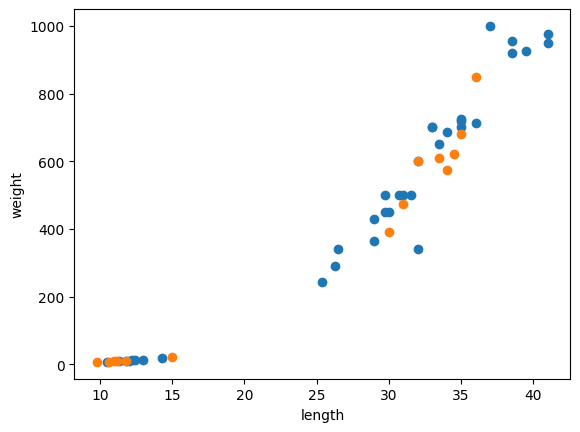

In [13]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(test_input[:,0], test_input[:,1])
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [14]:
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [15]:
fish_data = np.column_stack((fish_length,fish_weight))
print(fish_data[:5])

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


In [16]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [17]:
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [18]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

In [19]:
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(36, 2) (13, 2)
(36,) (13,)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

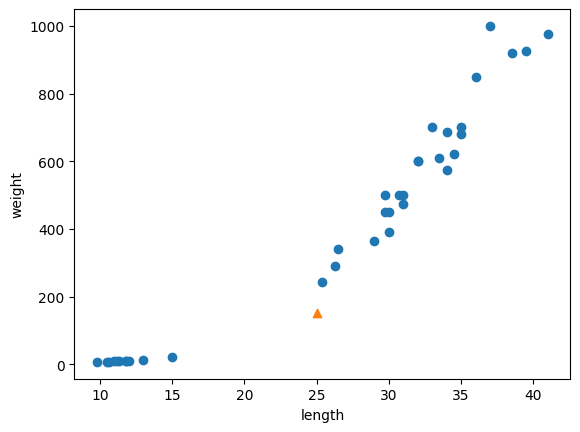

In [21]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [22]:
distances, indexes = kn.kneighbors([[25, 150]])

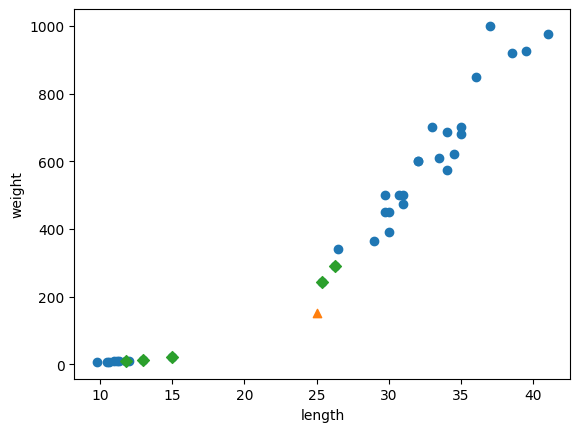

In [23]:
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [24]:
print(train_input[indexes])
print(train_target[indexes])
print(distances)

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 13.   12.2]
  [ 26.3 290. ]
  [ 11.8  10. ]]]
[[1. 0. 0. 1. 0.]]
[[ 92.00086956 130.48375378 138.32150953 140.00603558 140.62090883]]


In [25]:
mean=np.mean(train_input, axis=0)
std=np.std(train_input, axis=0)
print(mean, std)

[ 26.175      418.08888889] [ 10.21073441 321.67847023]


In [26]:
train_scaled=(train_input-mean)/std

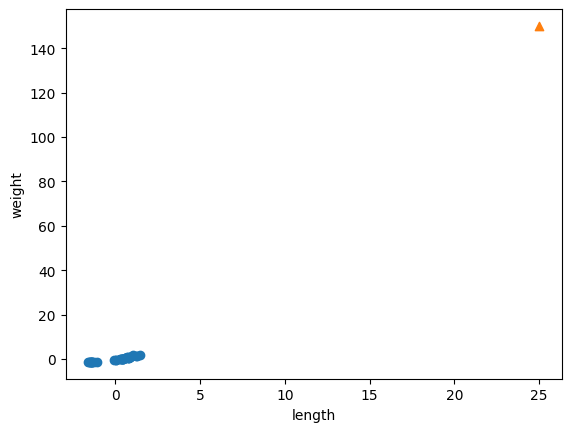

In [27]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

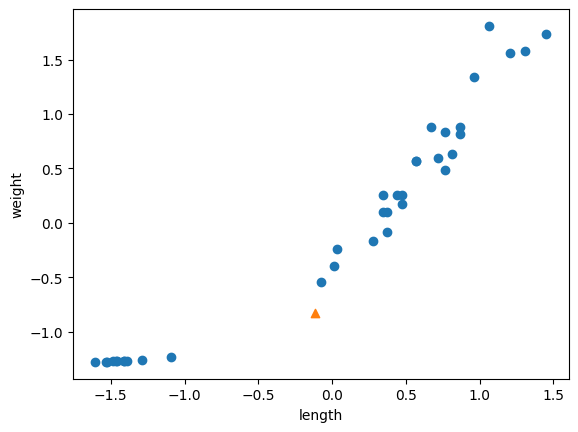

In [28]:
new=([25,150]-mean)/std
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [29]:
kn.fit(train_scaled,train_target)
test_scaled=(test_input-mean)/std
kn.score(test_scaled, test_target)
print(kn.predict([new]))

[1.]


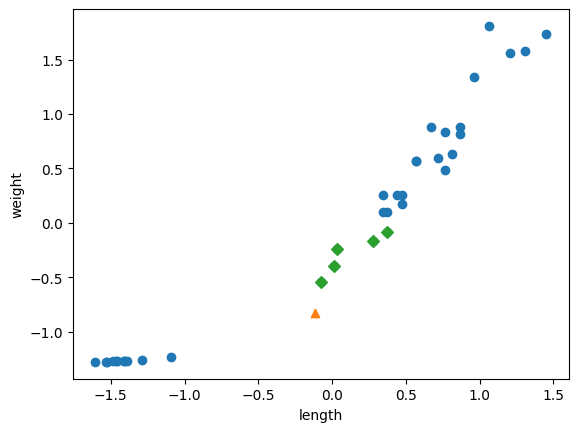

In [30]:
distances,indexes=kn.kneighbors([new])
plt.scatter(train_scaled[:,0],train_scaled[:,1])
plt.scatter(new[0],new[1],marker='^')
plt.scatter(train_scaled[indexes,0],train_scaled[indexes,1],marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(
    fish_data, fish_target, test_size=0.3, random_state=42
)
print(len(train_input_7), len(test_input_7))
print(len(train_target_7), len(test_target_7))

34 15
34 15


In [35]:
from sklearn.model_selection import train_test_split

train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(
    fish_data, fish_target, test_size=0.5, random_state=42
)
print(len(train_input_5), len(test_input_5))
print(len(train_target_5), len(test_target_5))

24 25
24 25


In [36]:
from sklearn.model_selection import train_test_split

train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(
    fish_data, fish_target, test_size=0.1, random_state=42
)
print(len(train_input_9), len(test_input_9))
print(len(train_target_9), len(test_target_9))

44 5
44 5


In [39]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier() # 정확도 테스트

kn.fit(train_input_7, train_target_7) # fit으로 훈련시키고 ,
print(kn.score(test_input_7, test_target_7))# score로 결과 확인

kn.fit(train_input_5, train_target_5) # fit으로 훈련시키고 ,
print(kn.score(test_input_5, test_target_5))# score로 결과 확인

kn.fit(train_input_9, train_target_9) # fit으로 훈련시키고 ,
print(kn.score(test_input_9, test_target_9))# score로 결과 확인


1.0
1.0
1.0


In [40]:
lengths = [fish[0] for fish in train_input]
weights = [fish[1] for fish in train_input]
n = len(train_input)

In [41]:
mean_length = sum(lengths)/n
mean_weight = sum(weights)/n

var_length = sum((lengths-mean_length)**2)/n
var_weight = sum((weights-mean_weight)**2)/n

std_length = var_length**0.5
std_weight = var_weight**0.5


In [47]:
train_scaled_manual = []
for fish in train_input:
  scaled_length = ((fish[0]-mean_length)/std_length)
  scaled_weight = ((fish[1]-mean_weight)/std_weight)
  train_scaled_manual.append([scaled_length,scaled_weight])
print(train_scaled_manual[:3])

[[np.float64(0.37460576740605944), np.float64(0.09920188655535014)], [np.float64(0.2766696190646061), np.float64(-0.17125451028601196)], [np.float64(0.3452249229036234), np.float64(0.2546365973837192)]]


In [43]:
print(f"수동 계산 평균: {mean_length:.2f}, {mean_weight:.2f}")
print(f"수동 계산 표준편차: {std_length:.2f}, {std_weight:.2f}")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")

수동 계산 평균: 26.17, 418.09
수동 계산 표준편차: 10.21, 321.68
스케일링된 첫 데이터: 0.37460576740605944


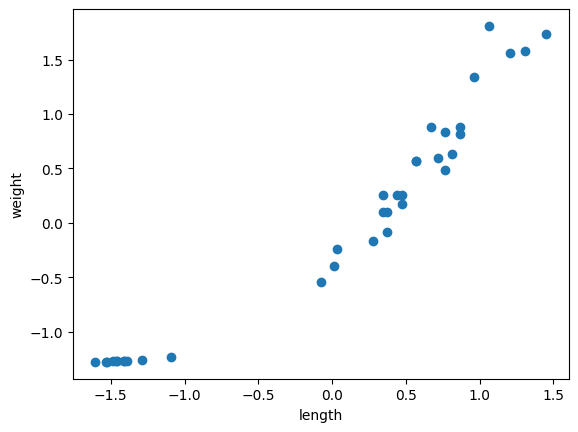

In [49]:
import matplotlib.pyplot as plt
scaled_lengths = [fish[0] for fish in train_scaled_manual]
scaled_weights = [fish[1] for fish in train_scaled_manual]
plt.scatter(scaled_lengths, scaled_weights)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()